In [ ]:
import pandas as pd
import numpy as np
#import seaborn as sns
import xarray as xr
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.tsa.stattools import ccf, grangercausalitytests
import matplotlib.cm as cm
import matplotlib.colors as mcolors
#import networkx as nx
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from matplotlib.colors import TwoSlopeNorm

In [3]:
def seasonal_average(da):
    da2=da.groupby('time.year').mean('time')
    return(da2)

def stdize_ssavg(da):
    da2=(da-da.mean())/da.std()
    return da2

def extract_seasonal_data(array, seasons):
    """
    Extract data from the array for specific seasons (months).
    - A subset of the original array with only the data for the specified months.
    """
    # Make sure the 'time' dimension has a 'month' coordinate
    if 'time' in array.coords:
        # Extract month from the 'time' dimension
        months = array['time'].dt.month
        
        # Filter based on the provided seasons (months)
        seasonal_data = array.sel(time=months.isin(seasons))
        
        return seasonal_data
    else:
        raise ValueError("The input array does not contain a 'time' dimension.")
        
def compute_anomaly(array):
    anomaly=array.groupby('time.month')-array.groupby('time.month').mean('time')
    return(anomaly)

def shift_december(da):
    time_df = pd.to_datetime(da['time'])
    # Create a boolean mask for times in December
    time_series=pd.Series(time_df)
    mask = time_series.dt.month == 12
    time_series.loc[mask] = time_series.loc[mask] + pd.DateOffset(years=1)
    # Convert to numpy datetime64[D]
    time_df_upd = time_series.values.astype('datetime64[D]')
    #display(time_df_upd)
    d={'time':time_df_upd}
    da_new=da.assign_coords(d)
    return da_new

def weight_by_latitude(da):
    """Weight data array by cosine of latitude."""
    weights = np.cos(np.deg2rad(da['lat']))
    weighted_da = da * weights
    return weighted_da

def sea_mask(da):
    landsea_mask=xr.open_dataset('landseamask.nc') # mask values 0 (sea) or 1 (land)
    landsea_mask_interp = landsea_mask['mask'].interp(
    lat=da.lat,
    lon=da.lon,
    method='nearest') ##map my mask 0.5° on my 0.25° grid
    #print(landsea_mask.sel(lat=-32.25,lon=-50.25)['mask'].values)
    
    masked_da=da.where(landsea_mask_interp==1)
    return masked_da

In [4]:
def df_xr_prep(df):
    da=df.to_xarray()
    da=da.rename({'index':'year'})
    return da

##La Plata
#SON
era_SON_LaPlata_df=pd.read_csv('data_ready/7.csv',index_col='Unnamed: 0')

#era_SON_LaPlata_df=era_SON_LaPlata_df.rename(index_col='year')
era_SON_LaPlata_array=era_SON_LaPlata_df.to_xarray()
era_SON_LaPlata_array=era_SON_LaPlata_array.rename({'index':'year'})

#DJF
era_DJF_LaPlata_df=pd.read_csv('data_ready/6.csv', index_col='Unnamed: 0')
era_DJF_LaPlata_array=df_xr_prep(era_DJF_LaPlata_df)

##Andes
#SON
era_SON_Andes_df=pd.read_csv('data_ready/5.csv',index_col='Unnamed: 0')
era_SON_Andes_array=df_xr_prep(era_SON_Andes_df)

#DJF
era_DJF_Andes_df=pd.read_csv('data_ready/4.csv', index_col='Unnamed: 0')
era_DJF_Andes_array=df_xr_prep(era_DJF_Andes_df)
display(era_DJF_Andes_array)

<xarray.Dataset>
Dimensions:        (year: 72)
Coordinates:
  * year           (year) int64 1951 1952 1953 1954 1955 ... 2021 2022 2023 2024
Data variables:
    t_Andes        (year) float64 -1.791 0.5614 -0.2617 ... 0.6274 0.7645 0.6017
    precip_Andes   (year) float64 0.129 0.4549 -1.375 ... -1.317 -0.2223 -1.51
    ENSO           (year) float64 -0.6866 0.5838 0.3068 ... -1.14 -0.7546 1.632
    IOD            (year) float64 0.2555 0.6281 1.26 ... -0.8422 0.9651 4.209
    EDJ            (year) float64 1.783 0.6677 -0.5056 ... 0.9377 0.1875
    EDJ_lat        (year) float64 -0.6985 1.359 -0.9556 ... -1.47 -2.241 -2.241
    EDJ_lat_nostd  (year) float64 -52.07 -48.64 -52.5 ... -53.36 -54.64 -54.64
    SPV            (year) float64 0.2633 -0.6312 1.451 ... 2.242 1.702 1.85
    A_SAM          (year) float64 0.233 -1.135 -2.197 ... 0.2581 1.774 0.05365
    S_SAM          (year) float64 0.6038 -1.058 0.1437 ... 1.631 1.93 1.88

In [5]:
def var_prepper(da, months_list, wghts_bool=True):
    ##1 Anomalies
    da_an=compute_anomaly(da)
    
    ##2 detrending
    p = da_an.polyfit(dim='time', deg=1, skipna=False)
    coeffs = p[list(p.data_vars)[0]]   # or p.t2m_polyfit_coefficients
    t_fit = xr.polyval(da_an['time'], coeffs)
    da_detr=da_an - t_fit
    
    ##3 weight by latitude (if necessary)
    if wghts_bool==True:
        da_wght=weight_by_latitude(da_detr)
    else:
        da_wght=da_detr
    ##4 extract seasonal data and standardise it again
    da_season=extract_seasonal_data(da_wght,months_list)
    if 12 in months_list:
        da_season_mean=stdize_ssavg(seasonal_average(shift_december(da_season)))
    else: 
        da_season_mean=stdize_ssavg(seasonal_average((da_season)))
        
    ##5 mask the ocean
    da_masked=sea_mask(da_season_mean)
    
    return da_masked

In [6]:
#load temperature era5 data
t_era=xr.open_dataset('data\era5_t2m.nc') #variable name is t2m
t_era=t_era.rename({'valid_time':'time','latitude':'lat','longitude':'lon'})
t_total=t_era.sel(time=slice('1950','2024'),lat=slice(-20,-55),lon=slice(-76,-49)) 

t_whole_SON=var_prepper(t_total, [9,10,11], wghts_bool=False)
t_whole_DJF=var_prepper(t_total, [12,1,2], wghts_bool=False)

C:\Users\giuli\AppData\Local\Temp\ipykernel_1060\1574557172.py:40: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  da_new=da.assign_coords(d)
C:\Users\giuli\AppData\Local\Temp\ipykernel_1060\1574557172.py:40: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be si

In [7]:
##Era 5 precip data
pr_era=xr.open_dataset('data\era5_tp.nc')
pr_era=pr_era.rename({'valid_time':'time','latitude':'lat','longitude':'lon'})
pr_total=pr_era.sel(time=slice('1950','2024'),lat=slice(-20,-55),lon=slice(-76,-49)) 

pr_whole_SON=var_prepper(pr_total, [9,10,11], wghts_bool=False)
pr_whole_DJF=var_prepper(pr_total, [12,1,2], wghts_bool=False)

C:\Users\giuli\AppData\Local\Temp\ipykernel_1060\1574557172.py:40: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  da_new=da.assign_coords(d)
C:\Users\giuli\AppData\Local\Temp\ipykernel_1060\1574557172.py:40: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be si

In [8]:
t_whole_SON.sel(lat=-32.25,lon=-50.25)

<xarray.Dataset>
Dimensions:  (year: 75)
Coordinates:
    lat      float64 -32.25
    lon      float64 -50.25
  * year     (year) int64 1950 1951 1952 1953 1954 ... 2020 2021 2022 2023 2024
Data variables:
    t2m      (year) float64 nan nan nan nan nan nan ... nan nan nan nan nan nan

In [9]:
print(np.unique(t_whole_SON.values))

[<bound method Mapping.values of <xarray.Dataset>
 Dimensions:  (year: 75, lat: 141, lon: 105)
 Coordinates:
   * lat      (lat) float64 -20.0 -20.25 -20.5 -20.75 ... -54.5 -54.75 -55.0
   * lon      (lon) float64 -76.0 -75.75 -75.5 -75.25 ... -50.5 -50.25 -50.0
   * year     (year) int64 1950 1951 1952 1953 1954 ... 2020 2021 2022 2023 2024
 Data variables:
     t2m      (year, lat, lon) float64 nan nan nan nan nan ... nan nan nan nan> ]


In [10]:
#display(t_LaPlata_ssavg_SON)

years_to_drop = [1950, 2002, 2019, 2025]

def exclude_years_xr(xr_obj, years):
    return xr_obj.sel(year=~xr_obj.year.isin(years))

##SON
t_whole_SON_ex=exclude_years_xr(t_whole_SON, years_to_drop)
pr_whole_SON_ex=exclude_years_xr(pr_whole_SON, years_to_drop)

##DJF
cut_years=[1950,2003,2020,2025]
t_whole_DJF_ex=exclude_years_xr(t_whole_DJF, cut_years)
pr_whole_DJF_ex=exclude_years_xr(pr_whole_DJF, cut_years)


In [11]:
##SON data
ds_SON = xr.merge([t_whole_SON_ex,pr_whole_SON_ex, era_SON_LaPlata_array])

##DJF data
ds_DJF=xr.merge([t_whole_DJF_ex,pr_whole_DJF_ex, era_DJF_LaPlata_array])

In [12]:
ds_SON.sel(lat=-30, lon=-50)

<xarray.Dataset>
Dimensions:         (year: 72)
Coordinates:
    lat             float64 -30.0
    lon             float64 -50.0
  * year            (year) int64 1951 1952 1953 1954 ... 2021 2022 2023 2024
Data variables:
    t2m             (year) float64 -1.51 -1.382 -0.02297 ... -0.738 0.3631 1.057
    tp              (year) float64 0.7865 -0.4533 1.368 ... -1.297 3.784 -1.324
    t_LaPlata       (year) float64 1.008 -0.3405 0.001028 ... -2.234 1.707 1.963
    precip_LaPlata  (year) float64 1.251 -1.636 2.576 ... -1.187 1.411 -0.9275
    ENSO            (year) float64 0.8577 -0.08958 0.6573 ... -1.065 1.719 -0.33
    IOD             (year) float64 0.1126 -0.4963 0.1753 ... -0.9812 3.25 0.8168
    EDJ             (year) float64 -0.4128 -0.3213 0.5606 ... -0.2175 -0.763
    EDJ_lat         (year) float64 1.568 -1.369 0.8338 ... -1.859 -0.1452 1.446
    EDJ_lat_nostd   (year) float64 -48.64 -53.79 -49.93 ... -54.64 -51.64 -48.86
    SPV             (year) float64 -1.639 0.7289 -1.065 ... 0.9296 -0.05547
    A_SAM           (year) float64 -0.6832 0.7533 0.5528 ... -0.6919 -0.4684
    S_SAM           (year) float64 -2.402 -0.386 -1.018 ... 2.036 0.5597 0.9627

In [13]:
def lin_model_xr(y, x_main, *x_controls):
    """
    y         : (year,)
    x_main    : (year,)   → main predictor (e.g. ENSO)
    x_controls: (year,)   → control predictors
    """

    X_list = [x_main]
    for x in x_controls:
        X_list.append(x)

    X = np.stack(X_list, axis=1)

    model = sm.OLS(y, X).fit()

    coef = model.params[0]
    pval = model.pvalues[0]

    return coef, pval


def construct_da_x_year_fix(da, year_fix):
    """
    Construct dictionary of rolling windows of length `year_fix` along time.

    Parameters
    ----------
    da : xarray.DataArray
        Input data with 'time' coordinate
    year_fix : int
        Number of years in each window

    Returns
    -------
    dict
        Keys: end year of window (int)
        Values: xarray.DataArray of shape (year_fix, ...)
    """
    df_dict = {}
    times = da.year.values
    n = len(times)

    for i in range(n - year_fix + 1):
        window = da.isel(year=slice(i, i + year_fix))
        end_year = int(window.year.values[-1])  # last year in window
        df_dict[end_year] = window

    return df_dict

def sensitivity_analysis2(dict_30, target, dep_var, indep_var_list=None, filename=None):
    coefs = []
    pvals = []
    years_end = []

    for year, ds in dict_30.items():

        # target (lat, lon, year)
        y = ds[target] 
        x=ds[dep_var] #driver variable
        # predictors (year,) or (lat, lon, year)
        if indep_var_list is not None:
            predictors = [ds[var] for var in indep_var_list] #controlled vars
        else:
            predictors=[]
        coef, pval = xr.apply_ufunc(
            lin_model_xr,
            y,
            x,
            *predictors,                          # <-- unpack list
            input_core_dims=[["year"]]*(2+len(predictors)),
            output_core_dims=[[], []],
            vectorize=True,
            output_dtypes=[float, float],
        )

        coefs.append(coef) #get slope
        pvals.append(pval) #get significance
        years_end.append(year)

    coef_da = xr.concat(coefs, dim="year").assign_coords(year=years_end)
    pval_da = xr.concat(pvals, dim="year").assign_coords(year=years_end)

    return coef_da, pval_da

def conditioning_everything3(somedict, driver_list, dep_var, skip=True, total_eff=False, filename=None):
    data_list=[]
    #name=dict_namer(somedict)
    #fig, axes=plt.subplots(nrows=1, ncols=len(driver_list), figsize=(8*len(driver_list)+4,8))
    for i, driver in enumerate(driver_list):
        to_be_removed=[driver]
        if total_eff==False: ##estimate direct effect
            driver_mod=[item for item in driver_list if item not in to_be_removed ]
            #print(driver_mod)
            if 'A_SAM' in driver_list and (driver=='SPV' or driver=='S_SAM'):
                driver_mod.remove('A_SAM')
            elif 'SPV' in driver_list and driver=='A_SAM':
                driver_mod.remove('SPV')
                driver_mod.remove('S_SAM')
        else: ## estimate total effect
            if driver=='IOD':
                driver_mod=['ENSO']
            elif driver=='SPV':
                driver_mod=['ENSO', 'IOD']
            else:
                driver_mod=None
                
        if skip==True:
            a=sensitivity_analysis2(somedict,dep_var,driver,driver_mod)
            print(driver+' is done.')
            mean=a[0].mean(dim='year')
            data_list.append(mean)
        else:
            a=somedict[i]
            
        if filename!=None:
            path='Netcdf_maps/'+filename+'/'+driver+'.nc'
            for element in data_list:
                element.to_netcdf(path=path, format='NETCDF4')
        #ax=axes[i] if len(driver_list) > 1 else axes[0]
        #hist_plot3(a, ax, dep_var)
        #plt.savefig(dep_var+str(list(name.keys()))+'3.jpg', bbox_inches='tight')
    return data_list

Whole Area Spring ERA5 data

In [14]:
temp_30_years=construct_da_x_year_fix(ds_SON, 30)

In [15]:
##this is the short cut
result=conditioning_everything3(temp_30_years, ['ENSO', 'IOD', 'SPV', 'A_SAM', 'S_SAM'], 't2m', filename='T_LP_SON')


KeyboardInterrupt: 

In [ ]:
pr_reg_LP_SON=conditioning_everything3(temp_30_years, ['ENSO', 'IOD', 'SPV', 'A_SAM', 'S_SAM'], 'tp', filename='Pr_LP_SON')

ENSO is done.
IOD is done.
SPV is done.
A_SAM is done.
S_SAM is done.


In [ ]:
import cartopy.feature as cfeature

def plot_map(
    i,
    da,
    title,
    units,
    fig,
    subplts_num,
    cmap=plt.cm.viridis,
    cbar_each=None,
    levels=None,
    pval=None,
    fontsize=14,
    smooth=False,
):
    """
    Plot a regional map using only the spatial extent of da with PlateCarree.

    Parameters
    ----------
    da : xarray.DataArray
        DataArray with dimensions (lat, lon)
    pval : xarray.DataArray, optional
        p-values on same grid as da
    """
    # Extract coordinates
    lat = da.lat.values
    lon = da.lon.values
    arr = da.values

    # Create axis with PlateCarree projection
    ax = fig.add_subplot(1, subplts_num, i, projection=ccrs.PlateCarree())

    # Set extent to data region only
    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())

    # Colormap normalization
    # ---- FIX: always center at zero ----
    if cbar_each is None:
        vmax = np.nanmax(np.abs(arr))
    else:
        vmax=cbar_each
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    # Plot the field
    if smooth:
        cs = ax.contourf(lon, lat, arr, norm=norm, transform=ccrs.PlateCarree(), cmap=cmap)
    else:
        cs = ax.pcolormesh(lon, lat, arr, norm=norm, transform=ccrs.PlateCarree(),
                           cmap=cmap, shading="auto")

    ax.coastlines(resolution="50m")        # still keep coastlines
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)  # add country borders

    # Title
    ax.text(0.01, 1.02, title, transform=ax.transAxes, fontsize=fontsize)
    ax.set_adjustable('box')

    # Colorbar
    # ---- individual colorbars ----
    if cbar_each is None:
        cbar_ax = ax.inset_axes([0.05, -0.12, 0.9, 0.07])
        cbar = plt.colorbar(cs, orientation="horizontal", cax=cbar_ax,fraction=0.046,
                pad=0.08)
        cbar.ax.tick_params(labelsize=fontsize)
        cbar.set_label(units, fontsize=fontsize)

    # Significance overlay
    if pval is not None:
        inds = np.argwhere(pval.values > 0.05)
        ax.plot(
            lon[inds[:, 1]],
            lat[inds[:, 0]],
            markersize=5.0,
            color="grey",
            marker=".",
            linestyle="None",
            transform=ccrs.PlateCarree(),
        )
    return cs

        
def subplots_map(ds, title_list, cmap=plt.cm.coolwarm, unit='K', cbar_each=None, heading=None):
    cs_list=[]
    fontsize=16
    global_max=0
    for da in ds:
        local_max = np.nanmax(np.abs(da.values))
        global_max = max(global_max, local_max)
        
    ##Find optimal figsize
    width_per_plot = 4
    height = 5 

    fig = plt.figure(figsize=(len(ds) * width_per_plot, height))
    fig.subplots_adjust(top=0.8)
    
    for j, da in enumerate(ds):
        
        cs=plot_map( #get the colorbar for each subplot
        i=j+1,
        da=da,
        pval=None,
        title=title_list[j],
        units=unit,
        cbar_each=global_max,
        fig=fig,
        subplts_num=len(ds),
        cmap=cmap,
        smooth=False,
        fontsize=fontsize)
        
        cs_list.append(cs)
    
    plt.tight_layout(rect=[0, 0.12, 1, 0.92])
    
    levels = np.linspace(-global_max, global_max, 7)  
    # → 10 color bins (adjust as you like)
    
    if not cbar_each:
        # create independent global norm
        global_norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

        sm = cm.ScalarMappable(norm=global_norm, cmap=cmap)
        sm.set_array([])
        
        cbar_ax = fig.add_axes([0.2, 0.08, 0.6, 0.03])
        cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
        cbar.ax.tick_params(labelsize=fontsize)
        cbar.set_label(unit, fontsize=fontsize)
        
    ##Heading
    if heading:
        fig.suptitle(heading, y=1.1, fontweight='bold', fontsize=18)
        fig.savefig('maps/'+heading+'.jpg', dpi=300, bbox_inches='tight')
    
    plt.show()

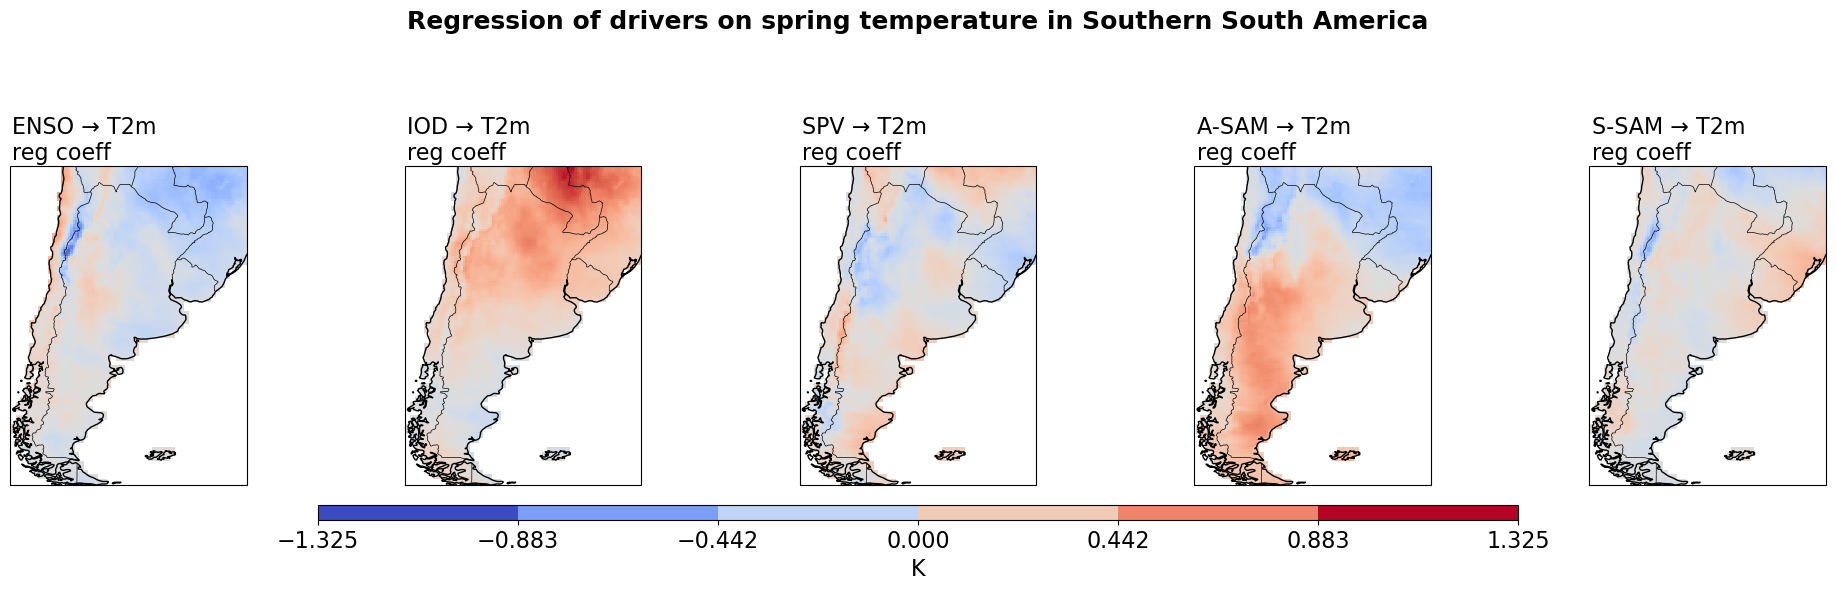

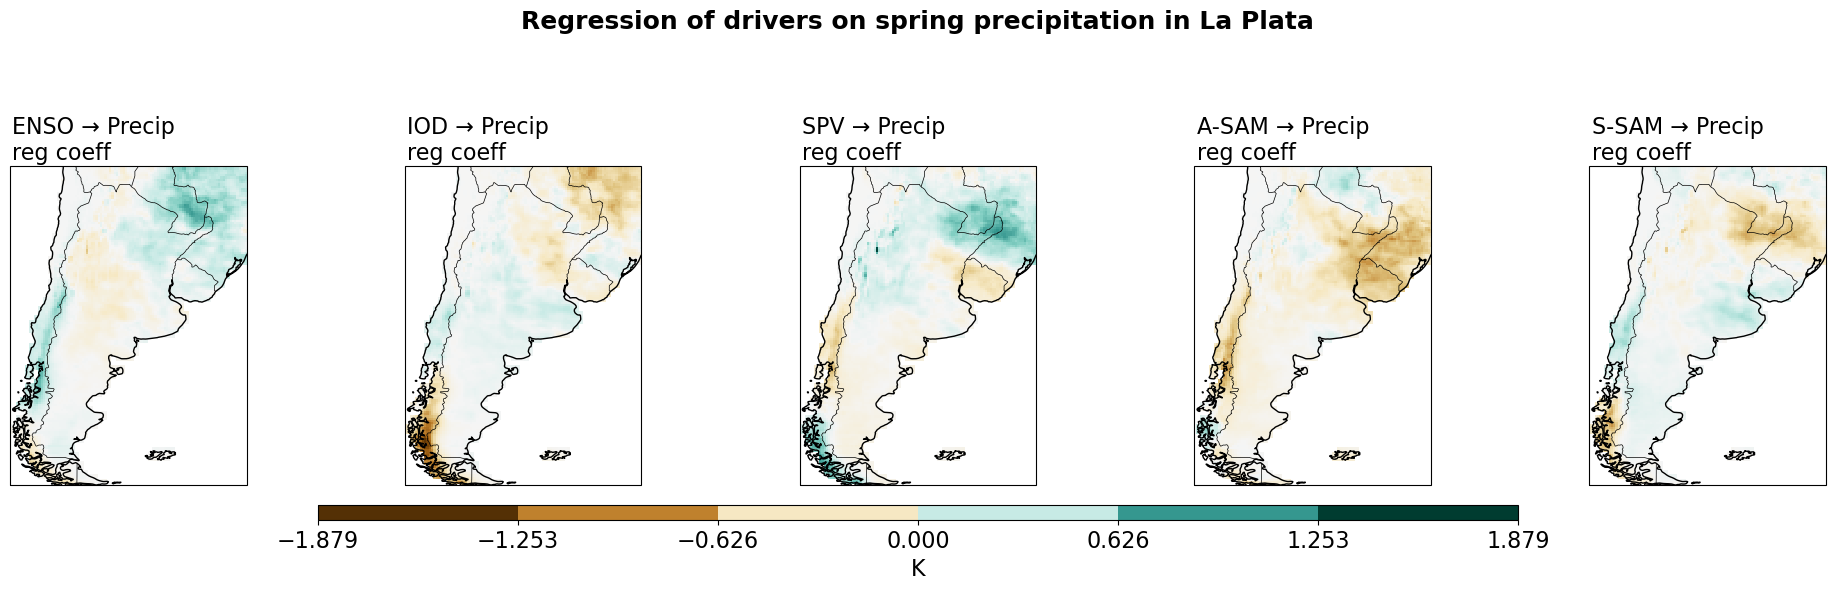

In [ ]:
#print(result)
subplots_map(result, [f"ENSO → T2m \nreg coeff", f"IOD → T2m \nreg coeff", f"SPV → T2m \nreg coeff", \
                      f"A-SAM → T2m \nreg coeff", f"S-SAM → T2m \nreg coeff"], heading='Regression of drivers on spring temperature in Southern South America')

subplots_map(pr_reg_LP_SON, [f"ENSO → Precip \nreg coeff", f"IOD → Precip \nreg coeff", f"SPV → Precip \nreg coeff", \
                      f"A-SAM → Precip \nreg coeff", f"S-SAM → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG ,heading='Regression of drivers on spring precipitation in La Plata')

In [ ]:
##total effect of temp and precip in LP
t_reg_LP_SON_tot=conditioning_everything3(temp_30_years, ['ENSO', 'IOD', 'SPV'], 't2m',total_eff=True, \
                                          filename='T_LP_SON_tot')
pr_reg_LP_SON_tot=conditioning_everything3(temp_30_years, ['ENSO', 'IOD', 'SPV'], 'tp',total_eff=True, filename='Pr_LP_SON_tot')

ENSO is done.
IOD is done.
SPV is done.
ENSO is done.
IOD is done.
SPV is done.


In [ ]:
display(t_reg_LP_SON_tot[0])

<xarray.DataArray (lat: 141, lon: 105)>
array([[       nan,        nan,        nan, ..., 0.22577129, 0.21230895,
        0.22136397],
       [       nan,        nan,        nan, ..., 0.22103846, 0.20878596,
        0.21848482],
       [       nan,        nan,        nan, ..., 0.21236841, 0.20960764,
        0.22083295],
       ...,
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]])
Coordinates:
  * lat      (lat) float64 -20.0 -20.25 -20.5 -20.75 ... -54.5 -54.75 -55.0
  * lon      (lon) float64 -76.0 -75.75 -75.5 -75.25 ... -50.5 -50.25 -50.0

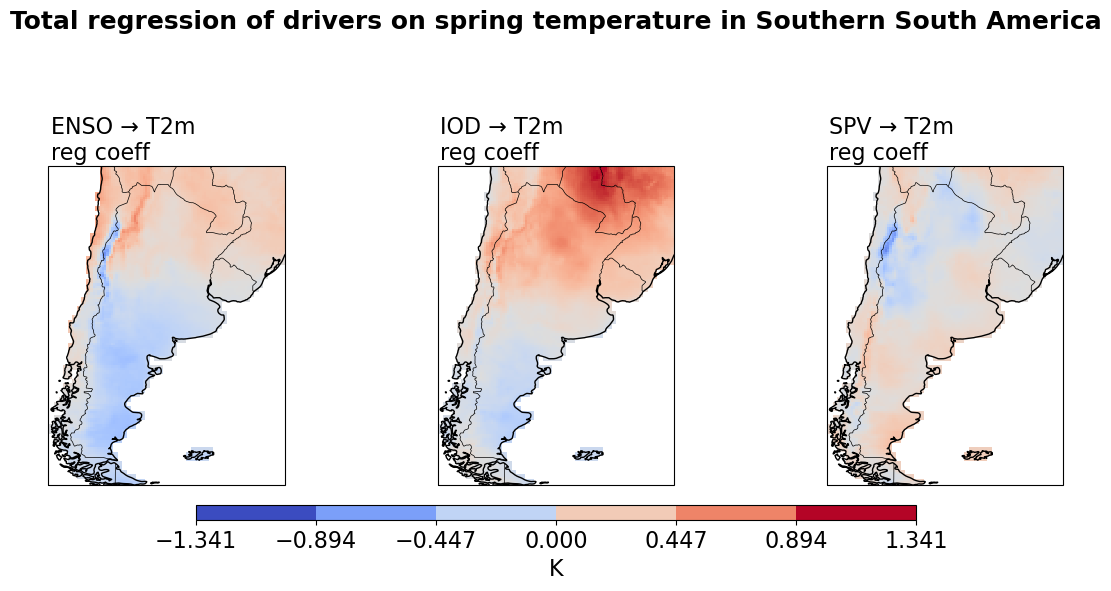

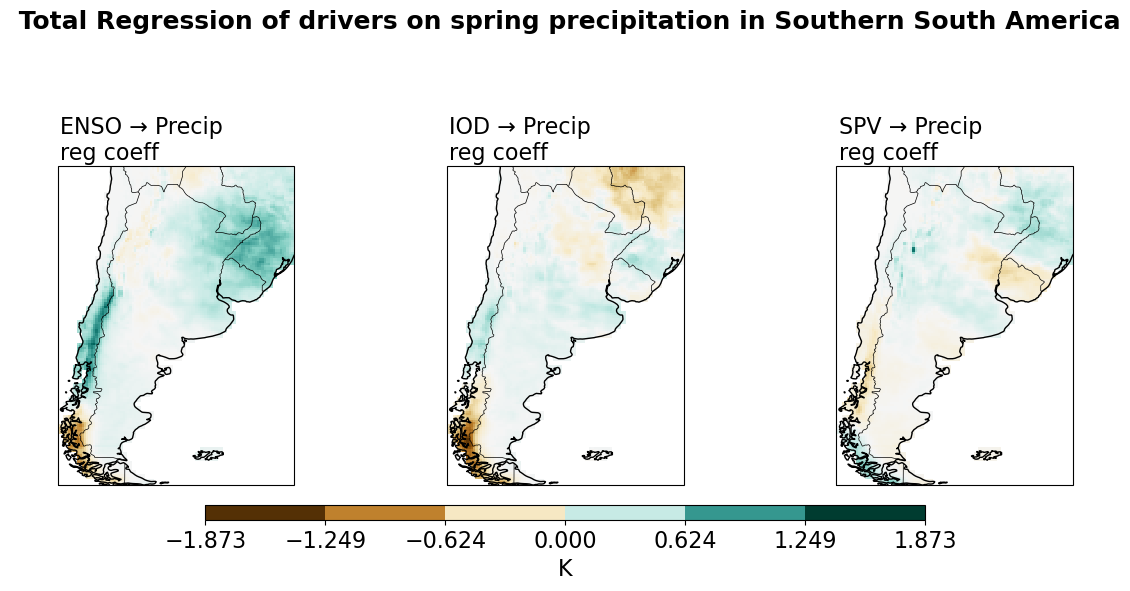

In [ ]:
subplots_map(t_reg_LP_SON_tot, [f"ENSO → T2m \nreg coeff", f"IOD → T2m \nreg coeff", f"SPV → T2m \nreg coeff", \
                      ], heading='Total regression of drivers on spring temperature in Southern South America')
subplots_map(pr_reg_LP_SON_tot, [f"ENSO → Precip \nreg coeff", f"IOD → Precip \nreg coeff", f"SPV → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG ,heading=' Total Regression of drivers on spring precipitation in Southern South America')

Whole Area Summer ERA5 data

In [ ]:
temp_30_years_LP_DJF=construct_da_x_year_fix(ds_DJF, 30)
LP_summer_t_reg=conditioning_everything3(temp_30_years_LP_DJF, ['ENSO', 'IOD', 'SPV', 'A_SAM', 'S_SAM'], 't2m', filename='T_LP_DJF')
LP_summer_pr_reg=conditioning_everything3(temp_30_years_LP_DJF, ['ENSO', 'IOD', 'SPV', 'A_SAM', 'S_SAM'], 'tp', filename='Pr_LP_DJF')

ENSO is done.
IOD is done.
SPV is done.
A_SAM is done.
S_SAM is done.
ENSO is done.
IOD is done.
SPV is done.
A_SAM is done.
S_SAM is done.


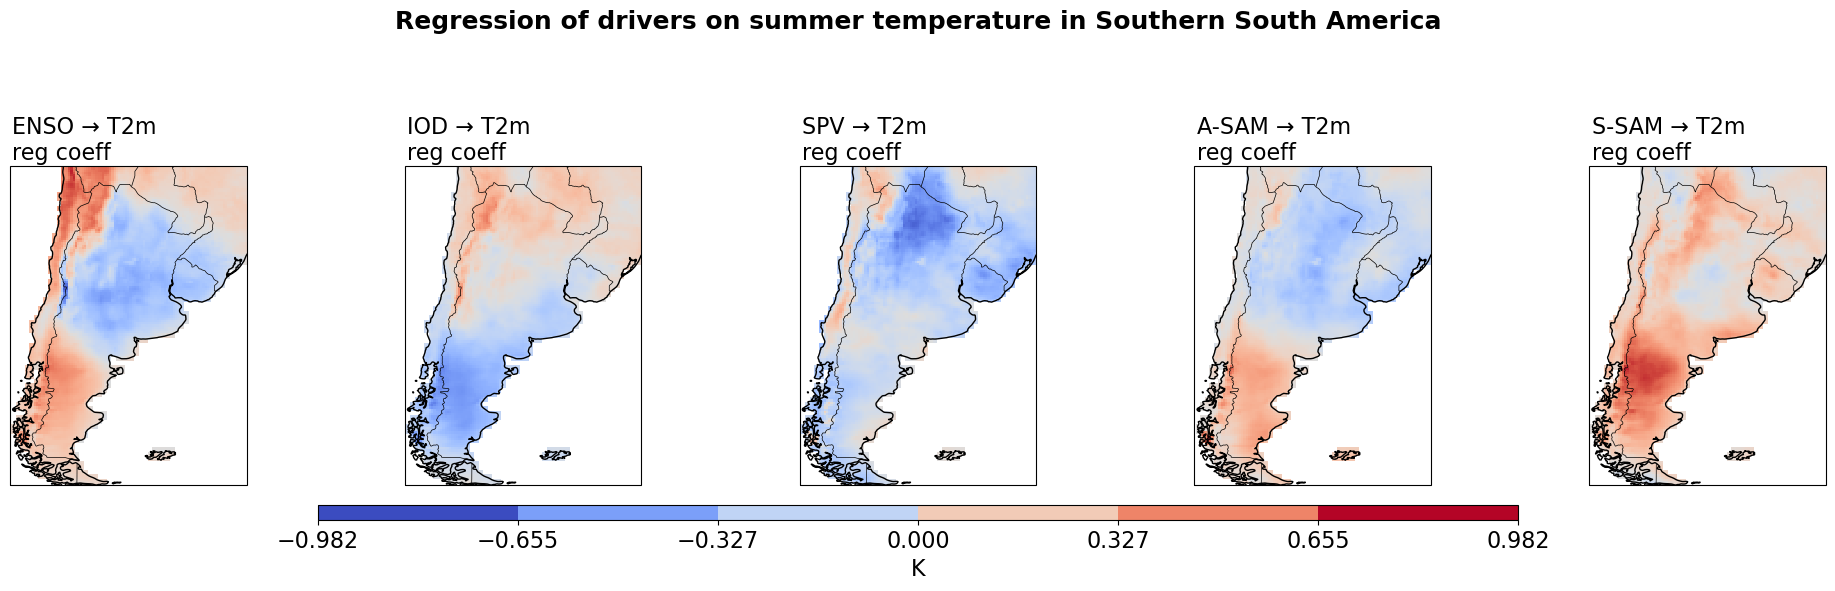

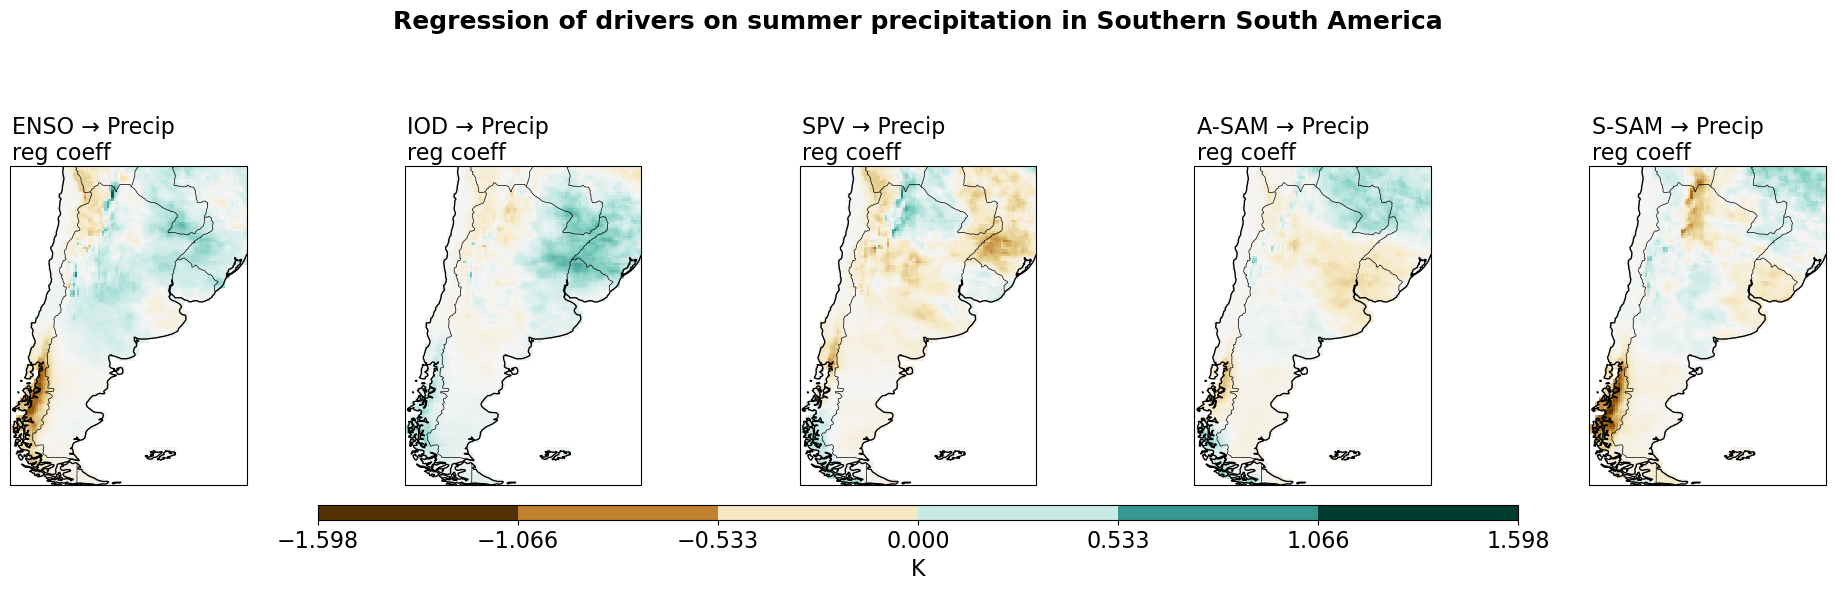

In [ ]:
#print(result)
subplots_map(LP_summer_t_reg, [f"ENSO → T2m \nreg coeff", f"IOD → T2m \nreg coeff", f"SPV → T2m \nreg coeff", \
                      f"A-SAM → T2m \nreg coeff", f"S-SAM → T2m \nreg coeff"], \
             heading='Regression of drivers on summer temperature in Southern South America')

subplots_map(LP_summer_pr_reg, [f"ENSO → Precip \nreg coeff", f"IOD → Precip \nreg coeff", f"SPV → Precip \nreg coeff", \
                      f"A-SAM → Precip \nreg coeff", f"S-SAM → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG ,heading='Regression of drivers on summer precipitation in Southern South America')

In [ ]:
##total effect of temp and precip in LP
t_reg_LP_DJF_tot=conditioning_everything3(temp_30_years_LP_DJF, ['ENSO', 'IOD', 'SPV'], 't2m',total_eff=True, filename='T_LP_DJF_tot')
pr_reg_LP_DJF_tot=conditioning_everything3(temp_30_years_LP_DJF, ['ENSO', 'IOD', 'SPV'], 'tp',total_eff=True, filename='Pr_LP_DJF_tot')

NameError: name 'conditioning_everything3' is not defined

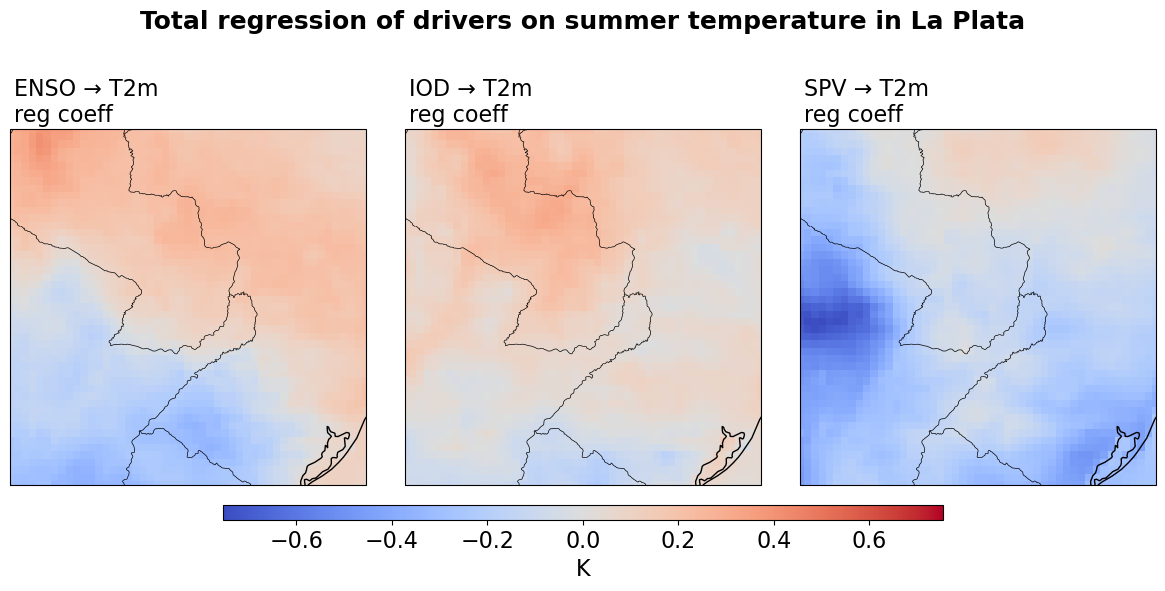

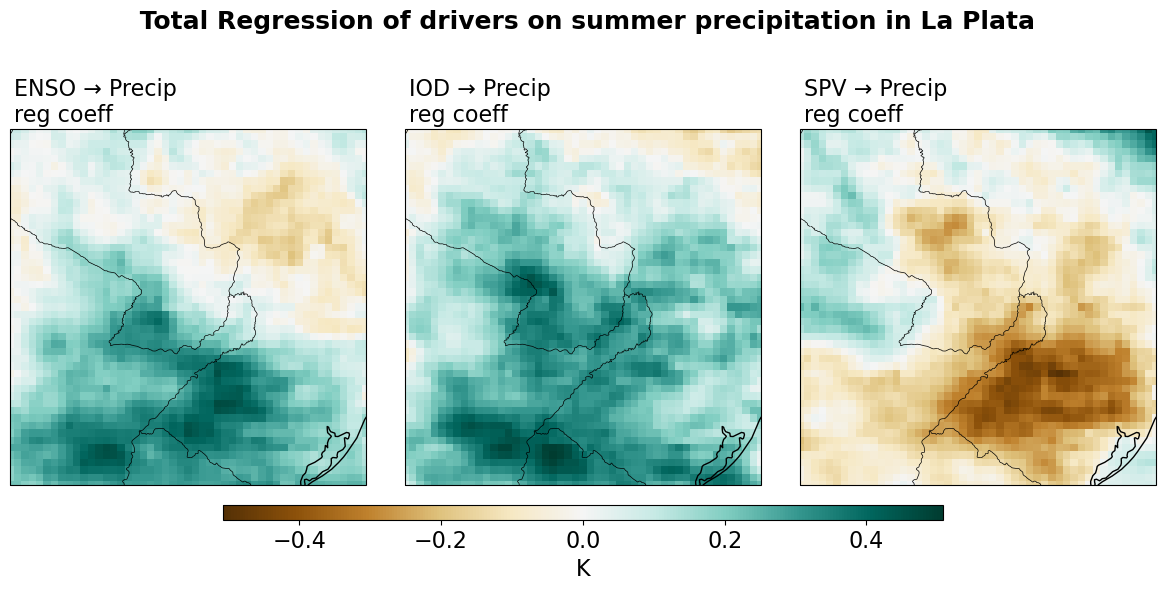

In [ ]:
subplots_map(t_reg_LP_DJF_tot, [f"ENSO → T2m \nreg coeff", f"IOD → T2m \nreg coeff", f"SPV → T2m \nreg coeff", \
                      ], heading='Total regression of drivers on summer temperature in Southern South America')
subplots_map(pr_reg_LP_DJF_tot, [f"ENSO → Precip \nreg coeff", f"IOD → Precip \nreg coeff", f"SPV → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG ,heading=' Total Regression of drivers on summer precipitation in Southern South America')